In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import random

In [ ]:
!unzip chest_xray.zip

Archive:  chest_xray.zip
   creating: chest_xray/
   creating: chest_xray/test/
   creating: chest_xray/test/NORMAL/
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0988-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0989-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0992-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0993-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0994-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0995-0001-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0995-0001-0002.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0995-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0997-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0998-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0999-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-1001-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-1002-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMA

In [ ]:
ls

chest_xray/  chest_xray.zip  drive/  sample_data/


In [ ]:
cd chest_xray/

/content/chest_xray


In [ ]:
ls

test/  train/


In [ ]:
cd train

/content/chest_xray/train


In [ ]:
ls

NORMAL/  PNEUMONIA/


In [ ]:
!ls NORMAL | wc -l
!ls PNEUMONIA | wc -l

1260
1260


In [ ]:
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/chest_xray/train',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    '/content/chest_xray/test',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 2520 images belonging to 2 classes.
Found 630 images belonging to 2 classes.


In [ ]:
img_size = 224
batch_size = 32
epochs = 15

In [ ]:
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
print(train_generator.samples)
print(test_generator.samples)
print(train_generator.class_indices)

2520
630
{'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 391s 5s/step - accuracy: 0.5196 - loss: 0.7912 - val_accuracy: 0.5000 - val_loss: 0.6986
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 384s 5s/step - accuracy: 0.5519 - loss: 0.6970 - val_accuracy: 0.7937 - val_loss: 0.6535
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 416s 5s/step - accuracy: 0.5715 - loss: 0.6750 - val_accuracy: 0.8397 - val_loss: 0.6375
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 402s 5s/step - accuracy: 0.6190 - loss: 0.6588 - val_accuracy: 0.8413 - val_loss: 0.6215
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 396s 5s/step - accuracy: 0.6370 - loss: 0.6505 - val_accuracy: 0.7460 - val_loss: 0.6148
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 401s 5s/step - accuracy: 0.6440 - loss: 0.6420 - val_accuracy: 0.8381 - val_loss: 0.5971
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 388s 5s/step - accuracy: 0.6458 - loss: 0.6388 - val_accuracy: 0.8397 - val_loss: 0.5866
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 395s 5s/step - accuracy: 0.6817 - loss: 0.6244 - val_accuracy: 0.8286 - v

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns

In [ ]:
results_path = "/content/drive/MyDrive/experiment_results/L_resnet_large_80_20"
os.makedirs(results_path, exist_ok=True)

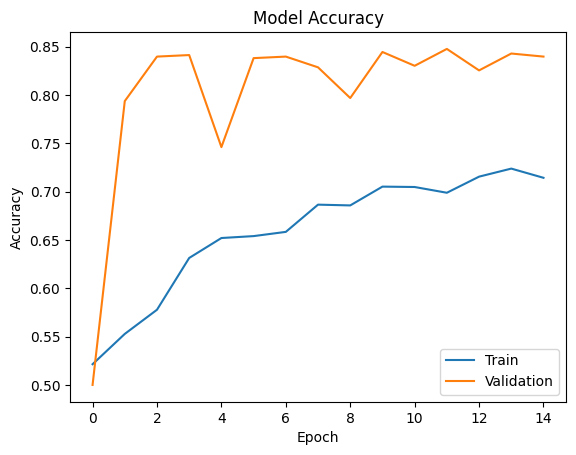

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.savefig(results_path + "/large_ResNetaccuracy_plot_80_20.png")
plt.show()

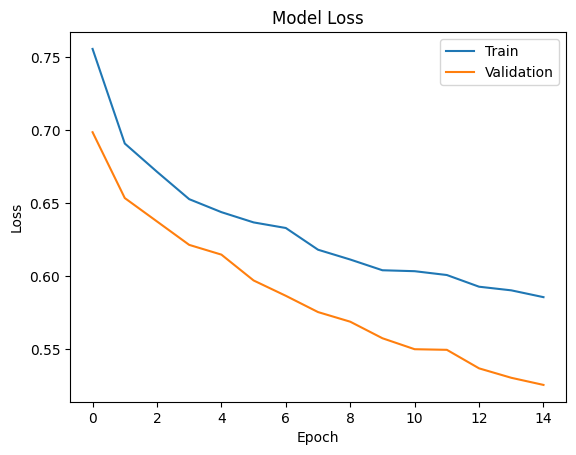

In [ ]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.savefig(results_path + "/large_ResNetloss_plot_80_20.png")
plt.show()

In [ ]:
test_generator.reset()
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).ravel()
y_true = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 78s 4s/step


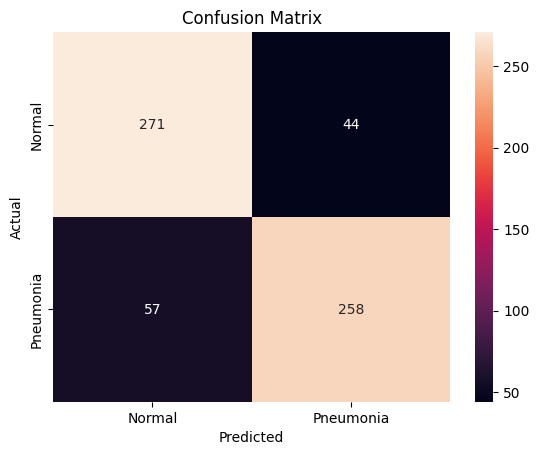

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.savefig(results_path + "/large_ResNetconfusion_matrix_80_20.png")
plt.show()

In [ ]:
report = classification_report(y_true, y_pred, target_names=['Normal','Pneumonia'])
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

print(report)
print("Weighted F1 Score:", weighted_f1)

              precision    recall  f1-score   support

      Normal       0.83      0.86      0.84       315
   Pneumonia       0.85      0.82      0.84       315

    accuracy                           0.84       630
   macro avg       0.84      0.84      0.84       630
weighted avg       0.84      0.84      0.84       630

Weighted F1 Score: 0.8396142474371804


In [ ]:
with open(results_path + "/large_ResNetclassification_report_80_20.txt", "w") as f:
    f.write(report)
    f.write("\nWeighted F1 Score: " + str(weighted_f1))

In [ ]:
final_val_acc = history.history['val_accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]

with open(results_path + "/large_final_metrics.txt", "w") as f:
    f.write("Final Validation Accuracy: " + str(final_val_acc) + "\n")
    f.write("Final Validation Loss: " + str(final_val_loss) + "\n")
    f.write("Weighted F1 Score: " + str(weighted_f1))